In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
%matplotlib inline

df = pd.read_csv('./survey_results_public.csv', low_memory=False)
df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


In [4]:
# Working with just quantitative variables is actually pretty straightforward 
# for most supervised learning techniques (except - we note that any row with 
# a missing value in any of the columns we use will be dropped -
# which might leave us with fewer predictions than we were hoping for).
# Let's just start and iterate on our findings

# Let's just fit something and go from there
df.describe()

,ResponseId,WorkExp,YearsCode,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,...,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,ConvertedCompYearly,JobSat
count,49191.000000,42893.000000,43042.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,...,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,2.394700e+04,26670.000000
mean,24596.000000,13.367403,16.570861,7.867352,4.104211,4.110271,5.678193,4.119388,5.225990,6.477387,...,5.718355,4.561767,4.790861,5.199657,5.676314,4.984653,7.099505,10.079284,1.017615e+05,7.201950
std,14200.362883,10.800117,11.787610,2.397432,2.275821,2.329536,2.398084,2.437945,2.801045,2.331468,...,2.628016,3.070548,2.643177,2.563562,2.310659,2.490095,2.469394,1.940928,4.617569e+05,1.997245
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,0.000000
25%,12298.500000,5.000000,8.000000,7.000000,2.000000,2.000000,4.000000,2.000000,3.000000,5.000000,...,3.000000,1.000000,3.000000,3.000000,4.000000,3.000000,6.000000,10.000000,3.817100e+04,6.000000
50%,24596.000000,10.000000,14.000000,9.000000,4.000000,4.000000,6.000000,4.000000,5.000000,7.000000,...,6.000000,4.000000,5.000000,5.000000,6.000000,5.000000,8.000000,10.000000,7.532000e+04,8.000000
75%,36893.500000,20.000000,24.000000,9.000000,6.000000,6.000000,8.000000,6.000000,8.000000,8.000000,...,8.000000,7.000000,7.000000,7.000000,7.000000,7.000000,9.000000,10.000000,1.205960e+05,8.000000
max,49191.000000,100.000000,100.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,5.000000e+07,10.000000


In [21]:
#Import the questions to be able to map them with the ids.
schema = pd.read_csv('./survey_results_schema.csv')
pd.set_option('display.max_rows', 200) 
pd.set_option('display.max_colwidth', None)  # show full question text without truncation
schema[['qname', 'question', 'sub']]

,qname,question,sub
0,TechEndorse_1,What attracts you to a technology or causes you to endorse it (most to least important)?,AI integration or AI Agent capabilities
1,TechEndorse_2,What attracts you to a technology or causes you to endorse it (most to least important)?,Easy-to-use API
2,TechEndorse_3,What attracts you to a technology or causes you to endorse it (most to least important)?,Robust and complete API
3,TechEndorse_4,What attracts you to a technology or causes you to endorse it (most to least important)?,Customizable and manageable codebase
4,TechEndorse_5,What attracts you to a technology or causes you to endorse it (most to least important)?,Reputation for quality
5,TechEndorse_6,What attracts you to a technology or causes you to endorse it (most to least important)?,Connected to an open-source project
6,TechEndorse_7,What attracts you to a technology or causes you to endorse it (most to least important)?,Good brand and public image
7,TechEndorse_8,What attracts you to a technology or causes you to endorse it (most to least important)?,Reliability and low latency
8,TechEndorse_9,What attracts you to a technology or causes you to endorse it (most to least important)?,Costs are manageable
9,TechEndorse_13,What attracts you to a technology or causes you to endorse it (most to least important)?,Other (please specify):


In [43]:
#Find the definitaion of specific question:
qname='ICorPM'
schema['full_question'] = schema['question']  + schema['sub'].fillna('')
display (schema[schema['qname'].str.contains(qname, case=False)][['qname', 'full_question']])

display (df[qname].value_counts().head(5)) # provides the 5 most common answers


,qname,full_question
62,ICorPM,Are you an individual contributor or people manager?


ICorPM
Individual contributor    28341
People manager             4902
Name: count, dtype: int64

In [10]:
df.columns.tolist()

['ResponseId',
 'MainBranch',
 'Age',
 'EdLevel',
 'Employment',
 'EmploymentAddl',
 'WorkExp',
 'LearnCodeChoose',
 'LearnCode',
 'LearnCodeAI',
 'AILearnHow',
 'YearsCode',
 'DevType',
 'OrgSize',
 'ICorPM',
 'RemoteWork',
 'PurchaseInfluence',
 'TechEndorseIntro',
 'TechEndorse_1',
 'TechEndorse_2',
 'TechEndorse_3',
 'TechEndorse_4',
 'TechEndorse_5',
 'TechEndorse_6',
 'TechEndorse_7',
 'TechEndorse_8',
 'TechEndorse_9',
 'TechEndorse_13',
 'TechEndorse_13_TEXT',
 'TechOppose_1',
 'TechOppose_2',
 'TechOppose_3',
 'TechOppose_5',
 'TechOppose_7',
 'TechOppose_9',
 'TechOppose_11',
 'TechOppose_13',
 'TechOppose_16',
 'TechOppose_15',
 'TechOppose_15_TEXT',
 'Industry',
 'JobSatPoints_1',
 'JobSatPoints_2',
 'JobSatPoints_3',
 'JobSatPoints_4',
 'JobSatPoints_5',
 'JobSatPoints_6',
 'JobSatPoints_7',
 'JobSatPoints_8',
 'JobSatPoints_9',
 'JobSatPoints_10',
 'JobSatPoints_11',
 'JobSatPoints_13',
 'JobSatPoints_14',
 'JobSatPoints_15',
 'JobSatPoints_16',
 'JobSatPoints_15_TEXT',
 

In [94]:
#Only take the columns that are interesting for the ML model. This is subjective
cols = ['MainBranch',
    # Demographics
    'Age', 'Country', 'EdLevel', 'Employment', 'WorkExp', 'YearsCode',

    # Job info
    'DevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'Industry', 'NewRole',

    # AI usage
    'AISelect', 'AISent', 'AIAcc', 'AIAgents', 'AIAgentChange', 'AIThreat',

    # Job satisfaction
    'JobSat',
    # Compensation (target)
    'ConvertedCompYearly'
]  # add your columns here
df_clean = df[cols]
df_clean = df_clean[df_clean['ConvertedCompYearly'].notnull()]
df_clean.head()

,MainBranch,Age,Country,EdLevel,Employment,WorkExp,YearsCode,DevType,OrgSize,ICorPM,...,Industry,NewRole,AISelect,AISent,AIAcc,AIAgents,AIAgentChange,AIThreat,JobSat,ConvertedCompYearly
0,I am a developer by profession,25-34 years old,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,8.0,14.0,"Developer, mobile",20 to 99 employees,People manager,...,Fintech,I have neither consider or transitioned into a new career or industry,"Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,"Yes, I use AI agents at work monthly or infrequently",Not at all or minimally,I'm not sure,10.0,61256.0
1,I am a developer by profession,25-34 years old,Netherlands,"Associate degree (A.A., A.S., etc.)",Employed,2.0,10.0,"Developer, back-end",500 to 999 employees,Individual contributor,...,Retail and Consumer Services,I have transitioned into a new career and/or industry voluntarily,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,"No, and I don't plan to",Not at all or minimally,I'm not sure,9.0,104413.0
2,I am a developer by profession,35-44 years old,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-employed",10.0,12.0,"Developer, front-end",NaN,NaN,...,Software Development,I have transitioned into a new career and/or industry involuntarily,"Yes, I use AI tools daily",Favorable,Somewhat trust,"Yes, I use AI agents at work weekly","Yes, somewhat",No,8.0,53061.0
3,I am a developer by profession,35-44 years old,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,4.0,5.0,"Developer, back-end","10,000 or more employees",Individual contributor,...,Retail and Consumer Services,I have neither consider or transitioned into a new career or industry,"Yes, I use AI tools weekly",Favorable,Somewhat trust,"Yes, I use AI agents at work monthly or infrequently",Not at all or minimally,No,6.0,36197.0
4,I am a developer by profession,35-44 years old,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-employed",21.0,22.0,Engineering manager,NaN,NaN,...,Software Development,I have neither consider or transitioned into a new career or industry,"Yes, I use AI tools weekly",Favorable,Neither trust nor distrust,"No, and I don't plan to","Yes, to a great extent",No,7.0,60000.0


In [95]:
##Check column summary
summary = []

for col in df_clean.columns:
    col_type = df_clean[col].dtype
    n_unique = df_clean[col].nunique(dropna=True)
    n_missing = df_clean[col].isnull().sum()

    summary.append({
        "column": col,
        "type": str(col_type),
        "unique_values": n_unique,
        "missing_values": n_missing
    })

summary_df = pd.DataFrame(summary).sort_values(by="unique_values", ascending=False)

print(summary_df)



                 column     type  unique_values  missing_values
20  ConvertedCompYearly  float64           6237               0
2               Country   object            164               0
5               WorkExp  float64             66             478
6             YearsCode  float64             66             109
7               DevType   object             32               0
11             Industry   object             15             914
19               JobSat  float64             11            4498
8               OrgSize   object              9            2743
3               EdLevel   object              8              17
1                   Age   object              7               0
0            MainBranch   object              6               0
4            Employment   object              6               0
14               AISent   object              6             821
16             AIAgents   object              6            1585
15                AIAcc   object        

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'EdLevel'}>,
        <Axes: title={'center': 'WorkExp'}>],
       [<Axes: title={'center': 'YearsCode'}>,
        <Axes: title={'center': 'OrgSize'}>,
        <Axes: title={'center': 'AISelect'}>],
       [<Axes: title={'center': 'AISent'}>,
        <Axes: title={'center': 'AIAgents'}>,
        <Axes: title={'center': 'JobSat'}>],
       [<Axes: title={'center': 'ConvertedCompYearly'}>, <Axes: >,
        <Axes: >]], dtype=object)

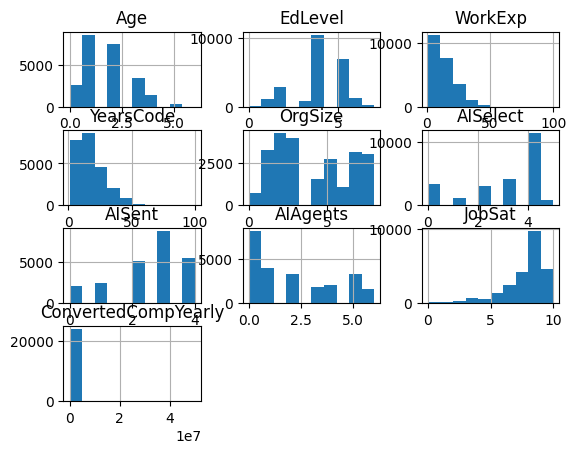

In [101]:
df_clean['Country'].value_counts().head(30)
df_clean.hist()

In [96]:
## Preprocessing steps

## Handle null values
# For numeric, use median
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    
#For categorical, classify as 'Unknown"
cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna("Unknown")
    ## Column Encoder
from sklearn.preprocessing import OrdinalEncoder

df_clean['EdLevel'] = df_clean['EdLevel'].replace({
    "Other (please specify):": "Unknown"
})
edlevel_order = [
    "Primary/elementary school",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",
    "Some college/university study without earning a degree",
    "Associate degree (A.A., A.S., etc.)",
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)",
    "Unknown"
]
df_clean['EdLevel'] = OrdinalEncoder(
    categories=[edlevel_order]
).fit_transform(df_clean[['EdLevel']])

## OrgSize
df_clean['OrgSize'] = df_clean['OrgSize'].replace({
    "Unknown": "I don’t know",
})
orgsize_order = [
    "Just me - I am a freelancer, sole proprietor, etc.",
    "Less than 20 employees",
    "20 to 99 employees",
    "100 to 499 employees",
    "500 to 999 employees",
    "1,000 to 4,999 employees",
    "5,000 to 9,999 employees",
    "10,000 or more employees",
    "I don’t know"
]
df_clean['OrgSize'] = OrdinalEncoder(
    categories=[orgsize_order]
).fit_transform(df_clean[['OrgSize']])

## Age
age_order = [
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older",
    "Prefer not to say"
]
df_clean['Age'] = OrdinalEncoder(
    categories=[age_order]
).fit_transform(df_clean[['Age']])

#AISent
df_clean['AISent'] = df_clean['AISent'].replace({
    "Unsure": "Indifferent",
    "Unknown": "Indifferent"
})
AIsent_order =  [
    "Very unfavorable",
    "Unfavorable",
    "Indifferent",
    "Favorable",
    "Very favorable"
]
df_clean['AISent'] = OrdinalEncoder(
    categories=[AIsent_order]
).fit_transform(df_clean[['AISent']])

#AIAgents
AIagent_order =  [
    "No, and I don't plan to",
    "No, but I plan to",
    "No, I use AI exclusively in copilot/autocomplete mode",
    "Yes, I use AI agents at work monthly or infrequently",
    "Yes, I use AI agents at work weekly",
    "Yes, I use AI agents at work daily",
    "Unknown"
]
df_clean['AIAgents'] = OrdinalEncoder(
    categories=[AIagent_order]
).fit_transform(df_clean[['AIAgents']])

#AISelect
AIselect_order =  [
    "No, and I don't plan to",
    "No, but I plan to soon",
    "Yes, I use AI tools monthly or infrequently",
    "Yes, I use AI tools weekly",
    "Yes, I use AI tools daily",
    "Unknown"
]
df_clean['AISelect'] = OrdinalEncoder(
    categories=[AIselect_order]
).fit_transform(df_clean[['AISelect']])

#Keep top 15 countries, group rest:
top_countries = df_clean['Country'].value_counts().nlargest(15).index
df_clean['Country'] = df_clean['Country'].apply(
    lambda x: x if x in top_countries else 'Other'
)

#Group DevType per category:
def group_devtype(dev):
    if pd.isnull(dev):
        return "Other"
    if "Developer" in dev:
        return "Developer"
    elif dev in ["Data scientist", "Data engineer", "Data or business analyst", "Applied scientist"]:
        return "Data"
    elif dev in ["AI/ML engineer", "Developer, AI apps or physical AI"]:
        return "AI"
    elif dev in ["DevOps engineer or professional", "Cloud infrastructure engineer"]:
        return "DevOps/Cloud"
    elif dev in ["Engineering manager", "Project manager", "Product manager"]:
        return "Management"
    elif dev in ["System administrator", "Database administrator or engineer", "Support engineer or analyst"]:
        return "IT Ops"
    elif dev == "Cybersecurity or InfoSec professional":
        return "Security"
    elif dev == "Architect, software or solutions":
        return "Architect"
    elif dev == "Academic researcher":
        return "Research"
    elif dev in ["Founder, technology or otherwise", "Senior executive (C-suite, VP, etc.)"]:
        return "Executive"
    else:
        return "Other"
df_clean['DevType'] = df_clean['DevType'].apply(group_devtype)

#Others no order:
df_prepared = pd.get_dummies(df_clean, columns=[
    'Country', 'DevType', 'Industry','AISent','MainBranch','Employment','AIAcc','RemoteWork','NewRole',
    'AIAgentChange','AIThreat','ICorPM'
], drop_first=True)

In [98]:
df_prepared.dtypes.value_counts()

bool       79
float64     9
Name: count, dtype: int64

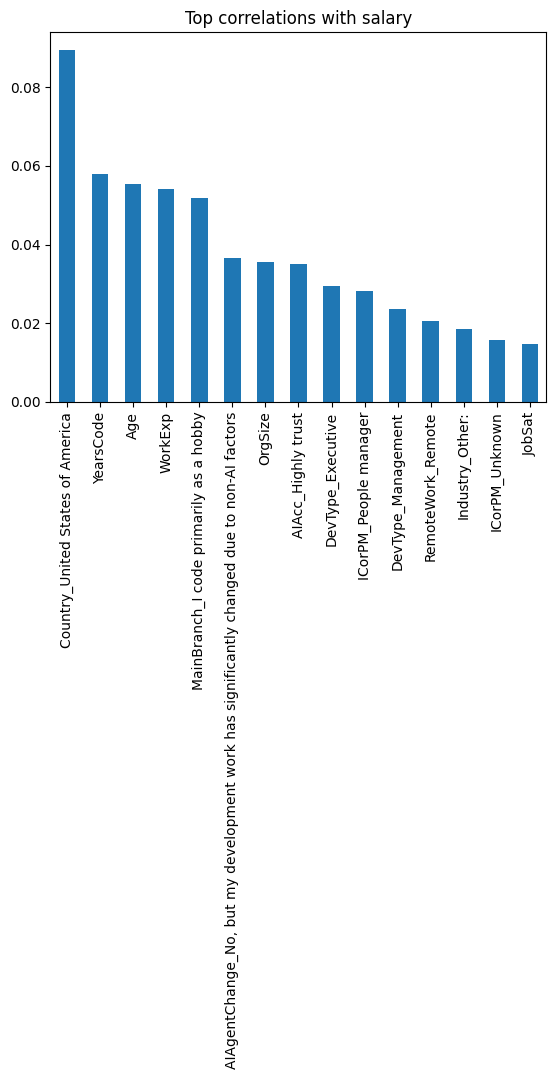

In [100]:
import matplotlib.pyplot as plt

top_corr = corr.drop('ConvertedCompYearly').head(15)

top_corr.plot(kind='bar')
plt.title("Top correlations with salary")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, ConfusionMatrixDisplay

X = df_prepared.drop(columns=['ConvertedCompYearly'])
y = df_prepared['ConvertedCompYearly']

X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2)

In [107]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train_log)

preds_log=xgb.predict(X_test)
preds = np.expm1(preds_log) # Convert back

rmse=root_mean_squared_error(y_test,preds)

r2 = r2_score(y_test, preds)

print (rmse, accuracy)

748477.3581690245 -0.021873488721736445


In [105]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr=lr.predict(X_test)
rmse=root_mean_squared_error(y_test, y_pred_lr)
accuracy= lr.score(X_test, y_test)
print (rmse, accuracy)

745074.161348222 0.010034543796736517
